In [2]:
import os
print(os.getcwd())


c:\Users\m8802\OneDrive\桌面\ai_cup\data_code


In [3]:
from TransactionAlertClassifier import LoadCSV
import pandas as pd
import numpy as np

In [4]:
dir_path = "./preliminary_data"
df_txn, df_alert, df_test = LoadCSV(dir_path)

print("交易資料 (df_txn):")
print(df_txn.shape)
print(df_txn.info())

print("\n警示帳戶 (df_alert):")
print(df_alert.shape)
print(df_alert.info())

print("\n預測帳戶清單 (df_test):")
print(df_test.shape)
print(df_test.info())


(Finish) Load Dataset.
交易資料 (df_txn):
(4435890, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4435890 entries, 0 to 4435889
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   from_acct       object 
 1   from_acct_type  int64  
 2   to_acct         object 
 3   to_acct_type    int64  
 4   is_self_txn     object 
 5   txn_amt         float64
 6   txn_date        int64  
 7   txn_time        object 
 8   currency_type   object 
 9   channel_type    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 338.4+ MB
None

警示帳戶 (df_alert):
(1004, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   acct        1004 non-null   object
 1   event_date  1004 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None

預測帳戶清單 (df_test):
(4780, 2)
<class 'pandas.core.frame.DataFrame'>
R

In [5]:
print(df_txn.head())
print(df_txn.columns)

                                           from_acct  from_acct_type  \
0  be6fdd2d0f9aa02b0b09436fb137654942e3346e16ab43...               1   
1  18f3d0e79217f8bc8b4cb485f9f80a884771b846de652f...               1   
2  302f3911cbf56bf9b5ad209a4b045a82380f98d92604c1...               1   
3  5a4809796865b1526f46e5dda6a35c1a4def3cbe969cc8...               1   
4  7f84214987bdee16ffbaf3d70824e6385ce80e032a24c5...               1   

                                             to_acct  to_acct_type  \
0  7abb16ac9bddc1f464981131ba68506775a964df2e0734...             1   
1  e77e425fb5f3ece7a7b431b3c43cc1d040f3054e35479d...             2   
2  4a707a0af2aa824777082803013610090033104c308023...             1   
3  d16b1bf33802f020b508002755c13aad549bc59dde7aae...             2   
4  c2e0f75b54f394b29755779ab9a488931e9d893a0e5f8f...             1   

  is_self_txn    txn_amt  txn_date  txn_time currency_type channel_type  
0           N    47500.0        71  05:05:00           TWD           04 

In [6]:
#統一金額基準
rate_map = {
    'TWD': 1.0, 'USD': 30.85, 'JPY': 0.1986, 'CNY': 4.31,
    'EUR': 35.4, 'HKD': 3.94, 'AUD': 20.07, 'GBP': 40.37,
    'CAD': 21.87, 'NZD': 17.5, 'THB': 0.935, 'ZAR': 1.74,
    'SGD': 23.6, 'CHF': 38.1, 'SEK': 3.21, 'MXN': 1.8
}

df_txn['rate'] = df_txn['currency_type'].map(rate_map).fillna(1.0)
#全部轉換成台幣
df_txn['txn_amt_twd'] = df_txn['txn_amt'] * df_txn['rate']

df_txn['txn_amt_twd'].describe(percentiles=[0.99])
#極度右偏 取對數讓模型學到相對變化
#讓模型把「倍數差」變成「加法差」
df_txn['txn_amt_twd_log'] = np.log1p(df_txn['txn_amt_twd'])
#提取小時特徵
#infer_datetime_format參數讓pd自己推格式
#origin定義起始點，將「天數差」轉成日期
#遇到奇怪的格式直接抱錯 
df_txn['txn_hour'] = pd.to_datetime(df_txn['txn_time'], format='%H:%M:%S', errors='coerce').dt.hour 
#np.nan 是唯一能被模型正確辨識的缺失值
df_txn['channel_type'] = df_txn['channel_type'].replace('UNK', np.nan)
#記憶體變小 pandas 的 category = 自動 label encoding + 類別資訊
df_txn['channel_type'] = df_txn['channel_type'].astype('category')
#布林列轉數字讓model吃
df_txn['is_self_txn_flag'] = (df_txn['is_self_txn'] == 'Y').astype(int)
df_txn['month'] = np.ceil(df_txn['txn_date'] / 30).astype(int)
#同群當前值-前一值，密集度
df_txn['month_diff'] = df_txn.groupby('from_acct')['txn_date'].diff()
#金流方向 fraud入款量多、出款集中
df_txn['direction'] = np.where(df_txn['from_acct_type'] == 1, 'out', 'in')
df_txn['direction'] = df_txn['direction'].astype('category')

- onehot-encode適合線性深度 但會維度爆炸 產生sparse
- labelencode 適合trea-based 多類別但non tree-based 會以為有順序姓
- tree-based 直接轉category 但linear svm logistic 一定要onehot技巧

In [7]:
df_txn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4435890 entries, 0 to 4435889
Data columns (total 18 columns):
 #   Column            Dtype   
---  ------            -----   
 0   from_acct         object  
 1   from_acct_type    int64   
 2   to_acct           object  
 3   to_acct_type      int64   
 4   is_self_txn       object  
 5   txn_amt           float64 
 6   txn_date          int64   
 7   txn_time          object  
 8   currency_type     object  
 9   channel_type      category
 10  rate              float64 
 11  txn_amt_twd       float64 
 12  txn_amt_twd_log   float64 
 13  txn_hour          int32   
 14  is_self_txn_flag  int64   
 15  month             int64   
 16  month_diff        float64 
 17  direction         category
dtypes: category(2), float64(5), int32(1), int64(5), object(5)
memory usage: 533.0+ MB


In [8]:
df_txn_train = df_txn[df_txn['txn_date'] <= 60]    # 約7–8月
df_txn_valid = df_txn[(df_txn['txn_date'] > 60) & (df_txn['txn_date'] <= 90)]
  # 約9月
df_txn_test = df_txn[df_txn['txn_date'] >90 ] # 10月
print(len(df_txn_train), len(df_txn_valid),len(df_txn_test ))


2215390 1101305 1119195


In [9]:
# 只保留與玉山帳戶有關的交易
df_txn_train = df_txn_train[
    (df_txn_train['from_acct_type'] == 1) | 
    (df_txn_train['to_acct_type'] == 1)
]

df_txn_valid = df_txn_valid[
    (df_txn_valid['from_acct_type'] == 1) | 
    (df_txn_valid['to_acct_type'] == 1)
]

df_txn_test = df_txn_test[
    (df_txn_test['from_acct_type'] == 1) | 
    (df_txn_test['to_acct_type'] == 1)
]


在交易資料中，一筆交易同時有匯出與收款帳戶。
若要讓模型理解「金流方向」，不能只加新欄位，必須分開聚合再合併。

先對 from_acct 聚合，得到出款行為；再對 to_acct 聚合，得到收款行為，最後以帳戶 ID 合併。
這樣模型才能同時看到「主動匯出」與「被動收款」的特徵。

若資料本來就是帳戶層級（已有流入、流出欄位），才可直接計算淨流入或出入比。
但在交易層級資料裡，唯有先分開建特徵、再合併，方向訊息才會被保留。

In [ ]:


#這個特徵工程想說明一件事:"這個帳戶在整個觀測期間內，其行為型態是否偏離一般帳戶？"

def build_side_features_enhanced(df_side: pd.DataFrame) -> pd.DataFrame:
    """
    High-performance fraud特徵工程（無 rolling → 最穩定＋最快）
    100% 不會爆 dtype / 不會產生 DataError / 適合大量資料
    """

    df = df_side.copy()

    # ===== 確保 dtype 正確 =====
    for col in ['txn_date', 'txn_amt_twd', 'txn_hour']:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['acct'] = df['acct'].astype(str)
    df['counter_acct'] = df['counter_acct'].astype(str)

    # ===== 基本衍生 =====
    df['weekday'] = df['txn_date'] % 7
    df['is_night'] = df['txn_hour'].between(0, 6)
    df['month'] = (df['txn_date'] // 30).astype(int)

    df['is_cross'] = (
        ((df['from_acct_type'] == 1) & (df['to_acct_type'] == 2)) |
        ((df['from_acct_type'] == 2) & (df['to_acct_type'] == 1))
    ).astype(int)

    df['is_self'] = df['is_self_txn_flag'].astype(int)

    # 重複金額
    df['is_repeat_amt'] = df.groupby('acct')['txn_amt_twd'] \
                            .transform(lambda x: x.duplicated(keep=False)).astype(int)

    # ===== 1. 單層 groupby → 極速 =====
    g = df.groupby('acct', observed=True)

    base = g.agg(
        txn_cnt=('txn_amt_twd', 'count'),
        amt_sum=('txn_amt_twd', 'sum'),
        amt_mean=('txn_amt_twd', 'mean'),
        amt_std=('txn_amt_twd', 'std'),
        amt_max=('txn_amt_twd', 'max'),
        hour_mean=('txn_hour', 'mean'),
        hour_std=('txn_hour', 'std'),
        night_ratio=('is_night', 'mean'),
        cross_bank_ratio=('is_cross', 'mean'),
        self_txn_ratio=('is_self', 'mean'),
        repeat_amount_ratio=('is_repeat_amt', 'mean'),
    ).reset_index()

    # ===== 2. Channel features =====
    ch = df.groupby(['acct', 'channel_type']).size().rename("cnt").reset_index()
    ch_total = ch.groupby('acct')['cnt'].sum()
    ch_top = ch.loc[ch.groupby('acct')['cnt'].idxmax()][['acct', 'cnt']]
    ch_top['channel_dominance'] = ch_top['cnt'] / ch_total[ch_top['acct']].values

    ch_feats = (
        ch.groupby('acct')['channel_type'].nunique()
        .rename("channel_nunique")
        .reset_index()
        .merge(ch_top[['acct','channel_dominance']], on='acct', how='left')
    )

    # ===== 3. Daily activity =====
    daily = df.groupby(['acct', 'txn_date']).size().rename("cnt").reset_index()
    d = daily.groupby('acct')

    day_feats = d.agg(
        active_days=('cnt','count'),
        avg_txn_per_day=('cnt','mean'),
        max_txn_in_day=('cnt','max'),
        day_std=('cnt','std'),
    ).reset_index()

    day_feats['activity_concentration'] = (
        day_feats['max_txn_in_day'] / (day_feats['avg_txn_per_day'] + 1e-6)
    )

    # ===== 4. Counterparty network =====
    cp = df.groupby(['acct','counter_acct']).size().rename("cnt").reset_index()
    cp_total = cp.groupby('acct')['cnt'].sum()
    cp_top = cp.loc[cp.groupby('acct')['cnt'].idxmax()][['acct','cnt']]
    cp_top['counterparty_top1_ratio'] = cp_top['cnt'] / cp_total[cp_top['acct']].values

    cp_feats = (
        cp.groupby('acct')['counter_acct'].nunique()
        .rename("counterparty_nunique")
        .reset_index()
        .merge(cp_top[['acct','counterparty_top1_ratio']], on='acct', how='left')
    )

    # ===== 5. Entropy（無 rolling → 安全）=====
    def fast_entropy(v):
        freq = v.value_counts(normalize=True)
        return -(freq * np.log2(freq)).sum()

    entropy_df = pd.concat([
        g['txn_hour'].apply(fast_entropy).rename("hour_entropy"),
        g['weekday'].apply(fast_entropy).rename("weekday_entropy")
    ], axis=1).reset_index()

    # ===== 6. 月份漂移（月平均變化）=====
    month_mean = df.groupby(['acct','month'])['txn_amt_twd'].mean()
    month_drift = month_mean.groupby(level=0).diff().groupby(level=0).mean().fillna(0)
    drift_df = month_drift.rename("avg_amt_drift").reset_index()

    # ===== 7. 最終合併 =====
    feats = (
        base.merge(ch_feats, on='acct', how='left')
            .merge(day_feats, on='acct', how='left')
            .merge(cp_feats, on='acct', how='left')
            .merge(entropy_df, on='acct', how='left')
            .merge(drift_df, on='acct', how='left')
            .fillna(0)
    )

    return feats


In [10]:
def run_feature(df_side, suffix):
    """
    df_side：from 或 to 的視角資料
    suffix：'_from' 或 '_to'
    """
    feats = build_side_features_enhanced(df_side)

    # 加 suffix （避免特徵名衝突）
    feats = feats.add_suffix(suffix)

    # 修正 acct 欄位命名（避免 acct__from 雙底線）
    feats = feats.rename(columns={f"acct{suffix}": f"acct_{suffix[1:]}"})

    return feats



In [11]:
from joblib import Parallel, delayed

def build_final_features(df_txn):

    # from 視角
    df_from = df_txn.rename(columns={'from_acct':'acct', 'to_acct':'counter_acct'}).copy()
    df_to   = df_txn.rename(columns={'to_acct':'acct', 'from_acct':'counter_acct'}).copy()

    # 避免 dtype 汙染
    for col in ['txn_date', 'txn_amt_twd', 'txn_hour']:
        if col in df_from:
            df_from[col] = pd.to_numeric(df_from[col], errors='coerce')
            df_to[col]   = pd.to_numeric(df_to[col], errors='coerce')

    df_from['counter_acct'] = df_from['counter_acct'].astype(str)
    df_to['counter_acct']   = df_to['counter_acct'].astype(str)
    df_from['acct'] = df_from['acct'].astype(str)
    df_to['acct']   = df_to['acct'].astype(str)

    # 平行化 from / to 特徵建構
    features_from, features_to = Parallel(
        n_jobs=-1,
        backend="loky"
    )([
        delayed(run_feature)(df_from, "_from"),
        delayed(run_feature)(df_to, "_to"),
    ])

    # 合併兩視角特徵
    df_features = (
        features_from.merge(
            features_to,
            left_on='acct_from',
            right_on='acct_to',
            how='outer'
        )
        .rename(columns={'acct_from': 'acct'})
        .drop(columns=['acct_to'])
        .fillna(0)
    )

    return df_features


In [12]:
df_features_train = build_final_features(df_txn_train)
df_features_valid = build_final_features(df_txn_valid)
df_features_test  = build_final_features(df_txn_test)


In [13]:
df_features_train = df_features_train.groupby("acct").first().reset_index()
df_features_valid= df_features_valid.groupby("acct").first().reset_index()
df_features_test = df_features_test.groupby("acct").first().reset_index()

In [14]:
df_alert['label'] = 1  # 每筆警示帳戶都是異常

df_train = (
    df_features_train 
    .merge(df_alert[['acct', 'label']], on='acct', how='left')
    .fillna({'label': 0})
)
df_valid = (
    df_features_valid
    .merge(df_alert[['acct','label']], on='acct', how='left')
    .fillna({'label': 0})
)



LightGBM Dataset格式
1. 特徵矩陣
2. 設定 label
3. 設定 weight


In [15]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np

# 純特徵矩陣
X_tr = df_train.drop(columns=['acct', 'label'])
y_tr = df_train['label']

# 特徵矩陣（valid）
X_val = df_valid.drop(columns=['acct', 'label'])
y_val = df_valid['label']

train_ds = lgb.Dataset(X_tr, label=y_tr)
val_ds = lgb.Dataset(X_val, label=y_val)

#optuna每一次 trial 要跑什麼
#trial 產生一組參數 → 用這組參數訓練模型 → 算 F1 → 回傳給 optuna

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': 5,
        'scale_pos_weight': (y_tr==0).sum() / (y_tr==1).sum(),
        'verbose': -1
    }

    model = lgb.train(
    params,
    train_ds,
    valid_sets=[val_ds],
    num_boost_round=trial.suggest_int('num_boost_round', 100, 2000), # 最大樹數 真正使用多少取決於 early stopping
    callbacks=[
        lgb.early_stopping(stopping_rounds=100), #若 validation 過去 100 棵樹都沒有更好，我就立刻停止訓練。防overfit
        lgb.log_evaluation(period=0)  # period=0 = 關閉 verbose 輸出
    ]
)


    # 模型預測的是每一筆資料為 1 的機率，fraud 的機率（0〜1）
    y_pred_prob = model.predict(X_val)
    # 對 threshold 做搜尋（0.1~0.9）
    thresholds = np.linspace(0.001, 0.02, 100)
    f1_scores = [f1_score(y_val, (y_pred_prob > t).astype(int)) for t in thresholds]
    best_f1 = max(f1_scores)
    best_t = thresholds[np.argmax(f1_scores)]

    trial.set_user_attr('best_threshold', best_t)
    return best_f1

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True) #讓 Optuna 重複跑 objective()50次每次試不同參數，找最佳 F1

print("Best F1:", study.best_value)
print("Best params:", study.best_params)
print("Best threshold:", study.best_trial.user_attrs['best_threshold'])

[I 2025-11-18 12:07:29,112] A new study created in memory with name: no-name-b672d29f-be87-43f2-b6fd-263cca6f0976


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's binary_logloss: 1.19139
[I 2025-11-18 12:07:41,399] Trial 0 finished with value: 0.003130915974952672 and parameters: {'learning_rate': 0.07391261944172085, 'num_leaves': 53, 'max_depth': 11, 'feature_fraction': 0.9667387355295856, 'bagging_fraction': 0.9336137237034587, 'num_boost_round': 1099}. Best is trial 0 with value: 0.003130915974952672.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's binary_logloss: 1.48996
[I 2025-11-18 12:07:51,908] Trial 1 finished with value: 0.001691165398292618 and parameters: {'learning_rate': 0.05308383447176328, 'num_leaves': 41, 'max_depth': 5, 'feature_fraction': 0.8981057247536715, 'bagging_fraction': 0.9925567716333877, 'num_boost_round': 149}. Best is trial 0 with value: 0.003130915974952672.
Training until validation scores don't improve for 100 rounds
Early stopping, best i

In [16]:
# ========== 取出最佳參數（補齊必要欄位） ==========
best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'verbose': -1
})
best_threshold_optuna = study.best_trial.user_attrs['best_threshold']

# ========== 使用 train + valid 重新訓練最終模型 ==========
X_all = pd.concat([X_tr, X_val], axis=0)
y_all = pd.concat([y_tr, y_val], axis=0)

train_all = lgb.Dataset(X_all, label=y_all)

final_model = lgb.train(
    best_params,
    train_all,
    num_boost_round=best_params['num_boost_round']
)

# ========== 在 validation 再次找 threshold ==========
y_val_prob = final_model.predict(X_val)

thresholds = np.linspace(0.01, 0.30, 60)
f1_scores = [f1_score(y_val, (y_val_prob > t).astype(int)) for t in thresholds]

final_threshold = thresholds[np.argmax(f1_scores)]

print("Final threshold:", final_threshold)


Final threshold: 0.22135593220338984


1. Optuna 用 train 找最佳模型參數（用 valid 評分）

2. 取出最佳參數

3. 用 train + valid 重訓一個最終模型

4. 用同一組 valid 重新找 threshold
為什麼 valid 能同時用來調參 + 找 threshold？

- Optuna 階段：模型只用 train 訓練，valid 只負責打分，不算訓練。
- 得到最佳參數後：用 train+valid 重訓 final model（這時不再調參）。
- threshold 調整是後處理，不會影響模型參數，也不算訓練。
- 真正的最終評分在 test，因此沒有資料洩漏。
→valid 的角色是「評分器 + 之後加入更多資料給 final model」，流程完全合理。

5. 完成最終模型

In [17]:
X_test = df_features_test.drop(columns=['acct'])
prob_test = final_model.predict(X_test)
pred_test = (prob_test > final_threshold).astype(int)


In [18]:
df_pred = pd.DataFrame({
    'acct': df_features_test['acct'],
    'prob': prob_test,
    'pred': pred_test
})
print(f"異常帳戶數量: {df_pred['pred'].sum()} / {len(df_pred)}")
print(f"異常比例: {df_pred['pred'].mean():.4%}")


異常帳戶數量: 113 / 331490
異常比例: 0.0341%


In [19]:
df_txn.to_csv("df_txn_clean.csv", index=False)
df_features_test.to_csv("df_features_full.csv", index=False)
df_pred.to_csv("df_model_output.csv", index=False)


In [20]:
print(df_txn.columns)
print(df_features_test.columns)
print(df_pred.columns)

Index(['from_acct', 'from_acct_type', 'to_acct', 'to_acct_type', 'is_self_txn',
       'txn_amt', 'txn_date', 'txn_time', 'currency_type', 'channel_type',
       'rate', 'txn_amt_twd', 'txn_amt_twd_log', 'txn_hour',
       'is_self_txn_flag', 'month', 'month_diff', 'direction'],
      dtype='object')
Index(['acct', 'txn_cnt_from', 'amt_sum_from', 'amt_mean_from', 'amt_std_from',
       'amt_max_from', 'hour_mean_from', 'hour_std_from', 'night_ratio_from',
       'cross_bank_ratio_from', 'self_txn_ratio_from',
       'repeat_amount_ratio_from', 'channel_nunique_from',
       'channel_dominance_from', 'active_days_from', 'avg_txn_per_day_from',
       'max_txn_in_day_from', 'day_std_from', 'activity_concentration_from',
       'counterparty_nunique_from', 'counterparty_top1_ratio_from',
       'hour_entropy_from', 'weekday_entropy_from', 'avg_amt_drift_from',
       'txn_cnt_to', 'amt_sum_to', 'amt_mean_to', 'amt_std_to', 'amt_max_to',
       'hour_mean_to', 'hour_std_to', 'night_ratio_t

In [21]:
esun_from = df_txn[df_txn['from_acct_type'] == 1]['from_acct']
esun_to   = df_txn[df_txn['to_acct_type'] == 1]['to_acct']

esun_accts = set(esun_from).union(set(esun_to))
print(f"玉山帳戶總數: {len(esun_accts)}")


玉山帳戶總數: 333768


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import numpy as np
import shap
import lightgbm as lgb
from sklearn.inspection import PartialDependenceDisplay


In [1]:
lgb.plot_importance(final_model, 
                    max_num_features=30, 
                    importance_type='gain',
                    figsize=(10, 12))
plt.title("Feature Importance (Gain)")
plt.show()


NameError: name 'lgb' is not defined

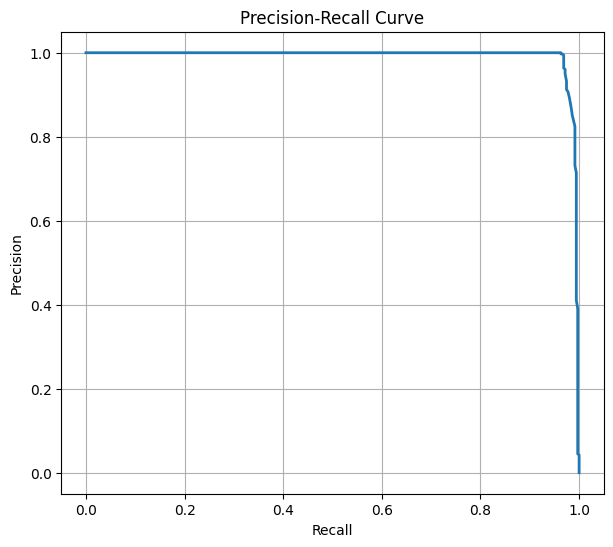

In [24]:
y_val_prob = final_model.predict(X_val)

precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()


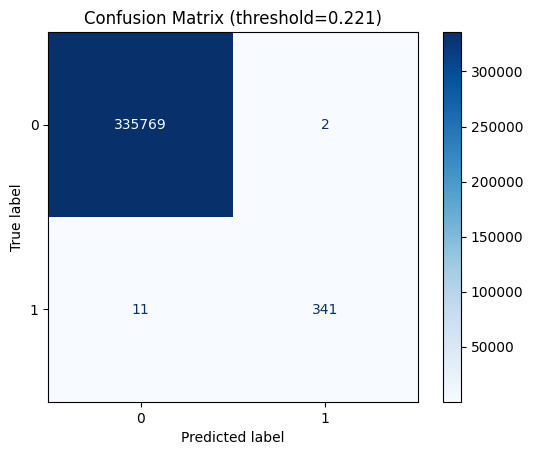

In [25]:
y_val_pred = (y_val_prob > final_threshold).astype(int)

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix (threshold={final_threshold:.3f})")
plt.show()
